In [1]:
# Import the packages
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Create dataframe
df = pd.read_csv('car_fuel_efficiency.csv')
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [3]:
# Get the columns
cols = [
    'engine_displacement',
    'horsepower',
    'vehicle_weight',
    'model_year',
    'fuel_efficiency_mpg'
]

df_copy = df[cols].copy()
df_copy.head()


,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369


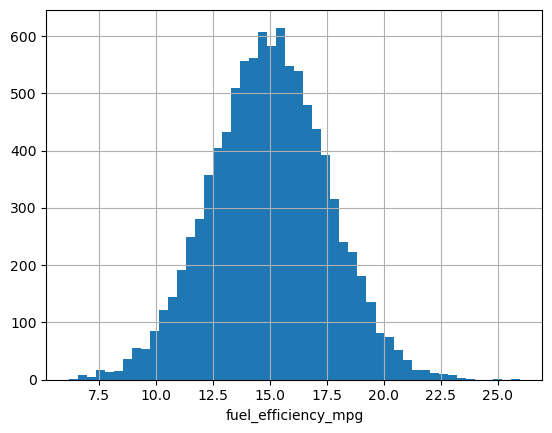

In [4]:
# EDA > Look at the fuel_efficiency_mpg variable. Does it have a long tail?
# Answer > bell curve so not a long tail
df_copy['fuel_efficiency_mpg'].hist(bins=50)
plt.xlabel('fuel_efficiency_mpg')
plt.show()

In [5]:
# Question 1 > There's one column with missing values. What is it?
# Answer > horsepower 
col_mv = df_copy.isnull().sum().sort_values(ascending=False)[df.isnull().sum() > 0]
col_mv

horsepower    708
dtype: int64

In [6]:
# Question 2 > What's the median (50% percentile) for variable 'horsepower'?
# Answer > 149
df_copy['horsepower'].median()

149.0

In [7]:
# Prepare and split the dataset
n = len(df_copy)

n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

# Shuffle the data with seed 42 to get the same shuffle
idx = np.arange(n)     
np.random.seed(42)      
np.random.shuffle(idx)  

df_shuffled = df_copy.iloc[idx]

# Create the different dataframes
df_train = df_shuffled.iloc[:n_train].copy().reset_index(drop=True)
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy().reset_index(drop=True)
df_test = df_shuffled.iloc[n_train+n_val:].copy().reset_index(drop=True)

# Get the targets
y_train = df_train['fuel_efficiency_mpg'].values
y_val = df_val['fuel_efficiency_mpg'].values
y_test = df_test['fuel_efficiency_mpg'].values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [8]:
# Question 3 > Fill missing values
# First create a matrix with the same length and width (X and X transform), because of the inverse
# We need the inverse because you can't divide a matrix, only multiplication
# All to find the best weight
def linear_regression(X, y):
    bias = np.ones(X.shape[0])
    X = np.column_stack([bias, X])
    X_T = X.T

    X_T_X = X_T.dot(X) 
    X_inverse = np.linalg.inv(X_T_X) # To get the inverse of a matrix, you need a non-singular matrix. It's not possible in a singular matrix

    w = X_inverse.dot(X_T).dot(y)

    return w[0], w[1:]


# Fill the null values with some number > fillna and get the values of this
def fill_nan(df, fill_values):
    df = df.fillna(fill_values)
    X = df.values
    return X


# Last but not least > calculate the rmse
def rmse_calc(y, y_pred):
    mse = np.mean((y - y_pred) ** 2)
    return np.sqrt(mse)


In [9]:
# Question 3 > With mean
mean_mv = df_train['horsepower'].mean()

X_train = fill_nan(df_train, fill_values=mean_mv)
w0, w = linear_regression(X_train, y_train)

X_val = fill_nan(df_val, fill_values=mean_mv)
y_pred = w0 + X_val.dot(w)

rmse_calc(y_val, y_pred)


np.float64(0.4635965042305247)

In [10]:
# Question 3 > With 0
X_train = fill_nan(df_train, fill_values=0)
w0, w = linear_regression(X_train, y_train)

X_val = fill_nan(df_val, fill_values=0)
y_pred = w0 + X_val.dot(w)

rmse_calc(y_val, y_pred)

# Question 3 > conclusion
# It's better to use the mean because of the lower RMSE 0.46 < 0.52

np.float64(0.5173782638849598)

In [11]:
# Question 4 > Train a regularized linear regression
def linear_regression_reg(X, y, alpha):
    bias = np.ones(X.shape[0])
    X = np.column_stack([bias, X])
    X_T = X.T

    X_T_X = X_T.dot(X)
    X_T_X = X_T_X + alpha * np.eye(X_T_X.shape[0]) # Add alpha to each diagonal element (identity matrix scaled by alpha) to regularize the weights 

    X_inverse = np.linalg.inv(X_T_X) # To get the inverse of a matrix, you need a non-singular matrix. It's not possible in a singular matrix

    w = X_inverse.dot(X_T).dot(y)

    return w[0], w[1:]

In [12]:
# There is no overfitting in the model, so the regularization of 00.1 is fine
r_number = [0, 0.01, 1, 10, 100]

for r in r_number:

    w_0, w = linear_regression_reg(X_train, y_train, r)
    y_pred = w_0 + X_val.dot(w)
    rmse_val = rmse_calc(y_val, y_pred)
    print(f"r={r}: rmse={round(rmse_val, 5)}")

r=0: rmse=0.51738
r=0.01: rmse=0.51711
r=1: rmse=0.52223
r=10: rmse=0.52298
r=100: rmse=0.52306


In [13]:
# Question 5 > Use different seeds to get the best one, seed gives you the same order of the data every time
seed = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
rmse_total = []

for s in seed:
    # Prepare and split the dataset
    n = len(df_copy)

    n_val = int(0.2 * n)
    n_test = int(0.2 * n)
    n_train = n - (n_val + n_test)

    # Shuffle the data with seed to get the same shuffle
    idx = np.arange(n)     
    np.random.seed(s)      
    np.random.shuffle(idx)  

    df_shuffled = df_copy.iloc[idx]

    # Create the different dataframes
    df_train = df_shuffled.iloc[:n_train].copy().reset_index(drop=True)
    df_val = df_shuffled.iloc[n_train:n_train+n_val].copy().reset_index(drop=True)
    df_test = df_shuffled.iloc[n_train+n_val:].copy().reset_index(drop=True)

    # Get the targets
    y_train = df_train['fuel_efficiency_mpg'].values
    y_val = df_val['fuel_efficiency_mpg'].values
    y_test = df_test['fuel_efficiency_mpg'].values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    X_train = fill_nan(df_train, fill_values=0)
    w0, w = linear_regression(X_train, y_train)

    X_val = fill_nan(df_val, fill_values=0)
    y_pred = w0 + X_val.dot(w)

    rmse_val = rmse_calc(y_val, y_pred)
    print(s, rmse_val)

    rmse_total.append(rmse_val)

0 0.5206531296280839
1 0.5213388912852643
2 0.5228069974618494
3 0.5159516741242552
4 0.5109129460021137
5 0.5283406460020179
6 0.5313910658148292
7 0.5090670387403644
8 0.5147399129451294
9 0.5131865908212457


In [14]:
# Get the standard deviation of the rmse_total
np.std(rmse_total)

# The answer on question 5 is 0.006

np.float64(0.006989446424468863)

In [15]:
# Question 6 > Use seed 9 and a 
n = len(df)
n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)

df_shuffled = df.iloc[idx]

df_train = df_shuffled.iloc[:n_train].copy().reset_index(drop=True)
df_val   = df_shuffled.iloc[n_train:n_train+n_val].copy().reset_index(drop=True)
df_test  = df_shuffled.iloc[n_train+n_val:].copy().reset_index(drop=True)

y_train = df_train['fuel_efficiency_mpg'].values
y_val   = df_val['fuel_efficiency_mpg'].values
y_test  = df_test['fuel_efficiency_mpg'].values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [ ]:
# Combine val and train dataset to get test
df_full_train = pd.concat([df_train, df_val]) # We use pd.concat because of the dataframes
y_full_train  = np.concatenate([y_train, y_val]) # We use np.concatenate because of the np.arrays

# Train with r=0.001
X_full_train = fill_nan(df_full_train, fill_values=0)
w0, w = linear_regression_reg(X_full_train, y_full_train, 0.001)

# Evaluate on test
X_test = fill_nan(df_test, fill_values=0)
y_pred = w0 + X_test.dot(w)

rmse_test = rmse_calc(y_test, y_pred)
print(round(rmse_test, 3))

# The answer on question 6 is 0.515